# Stock Data Extraction Using the yfinance Library

This notebook explores how to programmatically retrieve stock market data using the `yfinance` Python library. Rather than manually downloading CSVs, we connect directly to Yahoo Finance to pull live and historical data for two major technology stocks — **Apple (AAPL)** and **AMD (AMD)** — and analyze their price trends and dividend history.

**Stocks Covered:** Apple Inc. (AAPL) · Advanced Micro Devices (AMD)  
**Tools:** Python · yfinance · Pandas · Matplotlib

## Table of Contents
1. [Setup & Imports](#setup)
2. [Apple (AAPL) — Stock Overview](#apple)
   - Company Metadata
   - Historical Share Price
   - Dividend History
3. [AMD — Stock Overview](#amd)
   - Company Metadata
   - Historical Volume
4. [Key Findings](#findings)


In [1]:
# Install required libraries (run once)
!pip install yfinance matplotlib --quiet

## 1. Setup & Imports <a id='setup'></a>

In [2]:
import json
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

## 2. Apple (AAPL) — Stock Overview <a id='apple'></a>

Apple Inc. is one of the most valuable publicly traded companies in the world. We use its ticker symbol `AAPL` to retrieve metadata, price history, and dividend data.

In [3]:
apple = yf.Ticker("AAPL")

### Company Metadata

The `info` attribute returns a dictionary of key company details. We load it from a local JSON file to ensure consistency.

In [4]:
with open('apple.json') as f:
    apple_info = json.load(f)

print("Company:    ", apple_info['longName'])
print("Country:    ", apple_info['country'])
print("Sector:     ", apple_info['sector'])
print("Industry:   ", apple_info['industry'])
print("Market Cap: ", f"${apple_info['marketCap']:,}")

Company:     Apple Inc.
Country:     United States
Sector:      Technology
Industry:    Consumer Electronics
Market Cap:  $2,901,099,675,648


### Historical Share Price

Using `history(period='max')` we retrieve the full price history available on Yahoo Finance. The Opening price over time gives us a clear picture of Apple's long-term growth trajectory.

In [5]:
apple_data = apple.history(period="max")
apple_data.reset_index(inplace=True)

print(f"Data range: {apple_data['Date'].min().date()} → {apple_data['Date'].max().date()}")
print(f"Total trading days: {len(apple_data)}")
apple_data.head()

Data range: 1980-12-12 → 2026-03-27
Total trading days: 11414


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1980-12-12 00:00:00-05:00,0.098298,0.098725,0.098298,0.098298,469033600,0.0,0.0
1,1980-12-15 00:00:00-05:00,0.093597,0.093597,0.093169,0.093169,175884800,0.0,0.0
2,1980-12-16 00:00:00-05:00,0.086758,0.086758,0.086331,0.086331,105728000,0.0,0.0
3,1980-12-17 00:00:00-05:00,0.088468,0.088895,0.088468,0.088468,86441600,0.0,0.0
4,1980-12-18 00:00:00-05:00,0.091033,0.091460,0.091033,0.091033,73449600,0.0,0.0


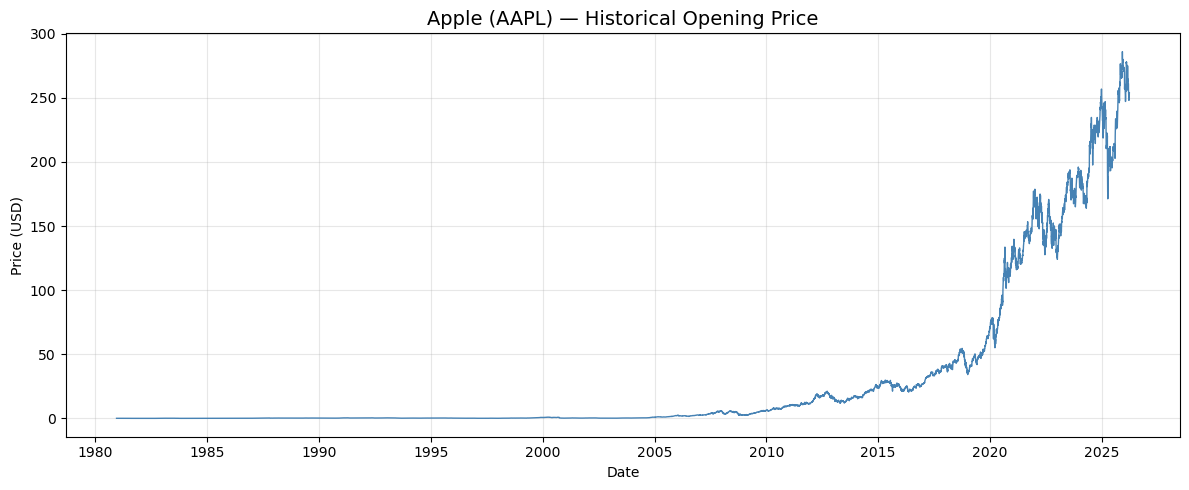

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(apple_data['Date'], apple_data['Open'], color='steelblue', linewidth=1)
plt.title('Apple (AAPL) — Historical Opening Price', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('aapl_price_history.png', dpi=150)
plt.show()

### Dividend History

Dividends reflect Apple's commitment to returning value to shareholders. The trend shows how dividend payments have grown over time.

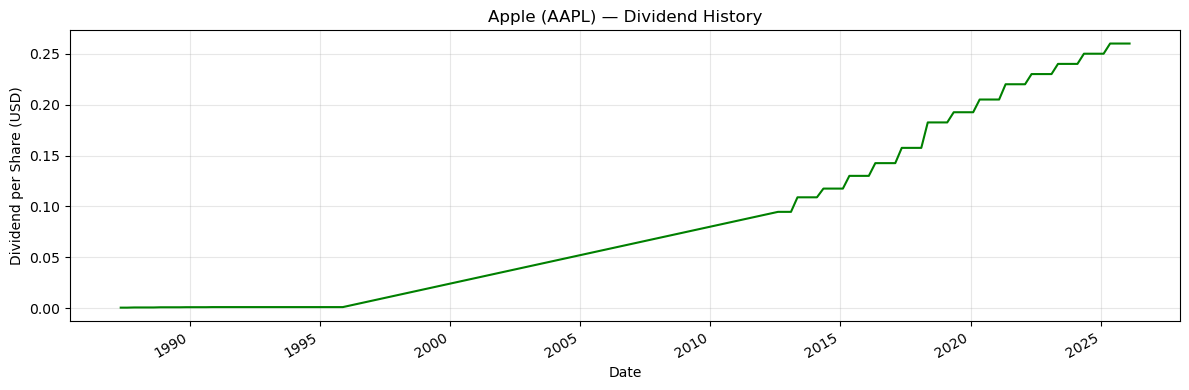

In [7]:
apple.dividends.plot(figsize=(12, 4), title='Apple (AAPL) — Dividend History', color='green')
plt.ylabel('Dividend per Share (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('aapl_dividends.png', dpi=150)
plt.show()

## 3. AMD — Stock Overview <a id='amd'></a>

Advanced Micro Devices (AMD) is a leading semiconductor company. We retrieve its metadata and analyze the volume of shares traded on its first recorded trading day.

In [8]:
amd = yf.Ticker("AMD")

with open('amd.json') as f:
    amd_info = json.load(f)

print("Company:    ", amd_info['longName'])
print("Country:    ", amd_info['country'])
print("Sector:     ", amd_info['sector'])
print("Industry:   ", amd_info['industry'])
print("Market Cap: ", f"${amd_info['marketCap']:,}")

Company:     Advanced Micro Devices, Inc.
Country:     United States
Sector:      Technology
Industry:    Semiconductors
Market Cap:  $194,013,855,744


In [9]:
amd_history = amd.history(period="max")

print(f"Data range: {amd_history.index.min().date()} → {amd_history.index.max().date()}")
print(f"Volume on first trading day: {amd_history['Volume'].iloc[0]:,}")

Data range: 1980-03-17 → 2026-03-27
Volume on first trading day: 219,600


## 4. Key Findings <a id='findings'></a>

This notebook demonstrated how to retrieve and explore stock data programmatically using `yfinance`:

- **Apple's growth trajectory:** AAPL's historical opening price chart reveals sustained long-term growth, with dramatic acceleration post-2019 reflecting the company's dominance in consumer electronics and services.
- **Dividend growth:** Apple's dividend payments have grown consistently since they were introduced in 2012, signaling a mature, shareholder-friendly company.
- **AMD's trading volume:** The first recorded trading day for AMD shows the early-stage market activity of what would become one of the most competitive semiconductor companies in the world.
- **API vs manual download:** Using `yfinance` eliminates the need for manual CSV downloads, enabling reproducible, always-current data pipelines for financial analysis.
